In [1]:
import numpy as np
from matplotlib import pyplot as plt
import sys
sys.path.append('../../SI-Figures/')
from myutils.process_AD import readResT_from_NERDSS

In [2]:
def onRate_macro2micro(ka_macro, D, sigma):
    if ka_macro < 1e-10:
        return 0
    else:
        return (1/ka_macro - 1/(4*np.pi*D*sigma))**-1

We perform spatial single-molecule simulations to quantify the dwell time of monomers, reversible dimers, and irreversible dimers binding nonspecific sites on DNA. Since the diffusion effect is hard to be captured in non-spatial models in 1D, for future generalization, we set our system at rate limit, $k_a << 4\pi D_{3D}\sigma$, where $k_a$ is the 3D microscopic association rate, $D_{3D}$ is the 3D diffusion constant, and $\sigma$ is the reaction radius. Here we choose $D_{3D} = 1.5\ \mu m^2 / s$ for protein monomers in nucleoplasm. For protein dimerization, P+P<->P_2, $\sigma=2\ nm$ and for protein binding nonspecific sites on DNA, $\sigma=1\ nm$. Once a protein monomer binds on DNA, its 1D diffusion constant is $D_{1D} = 0.6\ \mu m^2 / s$, which is at the upper limit of diffusion along DNA for our rate-limited assertion. We fix the protein dimerization strength to be $K_{A}^P = 10^6 M^{-1}$. We report all rates in 3D macroscopic manner ($k_{on}$ and $k_{off}$) and the microscopic rates used in NERDSS simulations are calculated as following:
$$
\frac{1}{k_a} = \frac{1}{k_{on}} - \frac{1}{4\pi D_{3D}\sigma} \\
k_b = k_a / K_A
$$
To capture the dimensionality effecy, we set $h^2=114\ nm^2$.

$N_N = 240$ and $N_P=2$ proteins nonspecific sites are randmly initialized in the system with L = 420 nm, and Ly=Lz=31.623 nm.

From Szabo's FPT theory, the association rate of PPN to N should be adjusted by ($b = L/(N_N-1)\approx1.75$):
$$
\frac{1}{k_{on}} = \frac{1}{k_a^N} + \frac{b-\sigma}{3D_{tot}}.
$$
Since the diffusion constant of N and PPN are $D_N=1\ \mu m^2 / s$ and $D_{PPN}=0.4286\ \mu m^2 / s$, respectively, we have $D_{tot}=1.4286\ \mu m^2 / s$
$$
k_{on} = \frac{0.0002}{0.175 \cdot 0.0002 + 1} \approx 0.000200
$$

From our model, the irreversible dimer's dwell time should be 
$$\left(1 + \frac{\gamma K_A^N\cdot [N]_{tot}}{2}\right)\cdot \tau_N,$$
which is an enhancement of a factor of $1.832$

In [46]:
(1 + (1000/114 * 200/0.6022 * 240/(420*1000) / 2)) / 0.6022

3.042792868173942

In [5]:
# for P+P
DPP = 1.5 * 2
sigmaPP = 2
KPP = 1e6 / 0.6022
# for P+N
DPN = 1.5
sigmaPN = 1
KPN = 200 / 0.6022
# kinetic rates for PN
kon = 200 * 1e-6
ka = onRate_macro2micro(kon, DPN, sigmaPN)
print('kaN = %.8f and kbN = %.4f'%tuple(np.round((ka, ka/KPN * 1e6), 4)))

kaN = 0.00020000 and kbN = 0.6022


In [26]:
1/0.6022

1.6605778811026237

In [6]:
kon = 0.1
ka = onRate_macro2micro(kon, DPP, sigmaPP)
print('kaP = %.4f and kbP = %.4f'%tuple(np.round((ka, ka/KPP * 1e6), 4)))

kaP = 0.1001 and kbP = 0.0603


In [7]:
kon = 1
ka = onRate_macro2micro(kon, DPP, sigmaPP)
print('kaP = %.4f and kbP = %.4f'%tuple(np.round((ka, ka/KPP * 1e6), 4)))

kaP = 1.0134 and kbP = 0.6103


In [8]:
kon = 10
ka = onRate_macro2micro(kon, DPP, sigmaPP)
print('kaP = %.4f and kbP = %.4f'%tuple(np.round((ka, ka/KPP * 1e6), 4)))

kaP = 11.5291 and kbP = 6.9428


In [41]:
NerdssRepeatIDs = [1,2,3]
dt = 1e-6
startT = 1e2

subdir_list = ['kpp1E6koffP10', 'kpp1E6koffP1', 'kpp1E6koffP01', 'dimer']
resT_list = []
for subdir in subdir_list:
    resTs = []
    for i in NerdssRepeatIDs:
        jobfolder = f'./{subdir}/nerdss_output/{i}'
        resTi, _ = readResT_from_NERDSS(
            jobfolder+'/DATA/assoc_dissoc_time.dat', dt, startT=startT
        )
        resTs.append(resTi)
    resT_list.append(resTs)
    
# kbN = 0.6022
[np.mean(np.concatenate(resTs))*0.6022 for resTs in resT_list]

[0.6958666295404718, 0.7760973601666202, 1.0733785787525916, 1.072849181387038]

In [42]:
[len(np.concatenate(resTs)) for resTs in resT_list]

[551, 719, 540, 324]

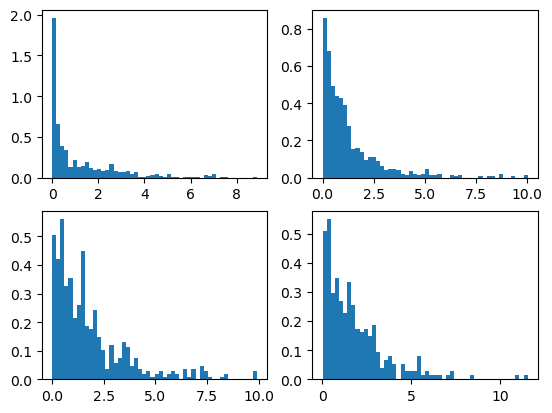

In [43]:
fig, axes = plt.subplots(2, 2)
plot_pos = [[0,0], [0,1], [1,0], [1,1]]
for i, resTs in enumerate(resT_list):
    axes[plot_pos[i][0]][plot_pos[i][1]].hist(np.concatenate(resTs), bins=50, density=True)

In [45]:
NerdssRepeatIDs = [1,2,3]
dt = 1e-6
startT = 1e2

# As a mistake, the monomer simulation has kbN = 1.6606
subdir_list = ['monomer']
resT_list = []
for subdir in subdir_list:
    resTs = []
    for i in NerdssRepeatIDs:
        jobfolder = f'./{subdir}/nerdss_output/{i}'
        resTi, _ = readResT_from_NERDSS(
            jobfolder+'/DATA/assoc_dissoc_time.dat', dt, startT=startT
        )
        resTs.append(resTi)
    resT_list.append(resTs)
    
# kbN = 0.6022
[np.mean(np.concatenate(resTs))*1.6606 for resTs in resT_list]

[0.9787176307253868]